# LSTM


LSTM(Long Short-Term Memory)은 **순환신경망(RNN, Recurrent Neural Network)**의 일종으로, RNN의 단점인 **장기 의존성 문제**를 해결하기 위해 고안된 신경망 구조이다.

**LSTM의 주요 특징**
1. **장기 의존성(Long-Term Dependency) 처리**
   - 일반적인 RNN은 시간이 길어질수록 과거의 정보를 잘 기억하지 못하는 **기울기 소멸(Gradient Vanishing)** 문제가 발생한다.
   - LSTM은 **Cell State**와 **게이트 구조**를 통해 중요한 정보를 장기적으로 유지할 수 있다.

2. **게이트(Gates) 구조**
   - LSTM은 정보를 선택적으로 기억하거나 잊게 해주는 3가지 게이트로 구성된다:
     - **입력 게이트(Input Gate):** 새로운 정보를 얼마나 저장할지 결정한다.
     - **망각 게이트(Forget Gate):** 기존 정보를 얼마나 잊을지 결정한다.
     - **출력 게이트(Output Gate):** 현재 상태를 출력에 얼마나 반영할지 결정한다.

3. **Cell State**
   - 네트워크의 **기억 장치** 역할을 하며, 중요하지 않은 정보는 제거하고 중요한 정보는 유지한다.


**LSTM의 구조**

![](https://d.pr/i/iPf2jG+)

아래는 LSTM의 한 타임스텝(time step)에서 이루어지는 연산 과정이다:

1. **망각 게이트 (Forget Gate)**  
    * 이전 상태 $h_{t-1}$와 입력 $x_t$를 통해 제거할 정보를 결정한다.

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

2. **입력 게이트 (Input Gate)**
    - 입력 게이트 $i_t$와 새로운 정보 $\tilde{C}_t$를 결합하여 Cell State에 반영할 정보를 생성한다.
    
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

3. **Cell State 업데이트**  
    * 이전 Cell State $C_{t-1}$와 새로운 정보의 조합으로 현재 Cell State를 업데이트한다.

$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

    

4. **출력 게이트 (Output Gate)**  
    * 출력 게이트 $o_t$와 업데이트된 Cell State $C_t$를 통해 새로운 은닉 상태 $h_t$를 계산한다.
    
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \cdot \tanh(C_t)
$$

**LSTM의 장점**

1. **장기 시퀀스 데이터 처리**: 시간의 흐름에 따라 발생하는 데이터를 잘 학습한다.
2. **텍스트, 음성, 시계열 데이터에 적합**: 언어 모델링, 번역, 주가 예측, 음성 인식 등 다양한 분야에서 활용된다.
3. **기울기 소멸 문제 해결**: Cell State와 게이트 구조 덕분에 학습이 안정적이다.

**추가 활용**

- **양방향 LSTM (Bidirectional LSTM)**: 양방향으로 데이터를 처리하여 더 많은 정보를 학습할 수 있다.
- **Stacked LSTM**: LSTM 레이어를 여러 층 쌓아 더 복잡한 패턴을 학습한다.

## LSTM 구조

In [1]:
# LSTM 입력/출력 텐서
import torch
import torch.nn as nn

batch_size = 2     # B : 한번에 처리할 샘플(문장) 개수
seq_len = 3        # T : 시퀀스 길이(Time Steps)
input_size = 4     # F : 각 시점의 입력 차원 (vocab_size 또는 임베딩 차원)
hidden_size = 5    # H : RNN의 은닉 상태 차원

x = torch.randn(batch_size, seq_len, input_size)    # 입력 시퀀스 텐서 생성 : (B, T, F)
print(x.shape)

# LSTM 생성 ((B, T, F) 형태로 입력을 받도록 설정)
lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
output, (hidden, cell) = lstm(x)    # 순전파 : output(전체 시점 출력), hidden(마지막 은닉)

print(output.shape)    # (B, T, H) : 모든 시점의 은닉 출력들이 쌓인 결과
print(hidden.shape)    # (Num_layers, B, H) : 마지막 시점 은닉 상태
print(cell.shape)      # (Num_layers, B, H) : 마지막 시점 cell state 

torch.Size([2, 3, 4])
torch.Size([2, 3, 5])
torch.Size([1, 2, 5])
torch.Size([1, 2, 5])


## IMDB 리뷰 감성분석
- IMDB 데이터는 영화 리뷰 텍스트와 그 리뷰의 감성(긍정/부정) 라벨로 구성된 이진 분류용 데이터셋
- 입력(X): 영화 리뷰 문장(원문 텍스트) → `tensorflow.keras.datasets.imdb`로 불러오면 “바로 모델에 넣어 실습할 수 있게” 미리 전처리된 형태(단어→정수 ID)로 제공
- 정답(y): 감성 라벨 0=부정, 1=긍정
- imdb.load_data(num_words=vocab_size)의 의미: 빈도 상위 vocab_size개 단어만 단어사전에 남기고, 나머지는(덜 나온 단어) 잘리거나 OOV로 처리되는 방식

- 결과적으로 **“영화 리뷰가 긍정인지 부정인지 맞추는 감성분류 데이터”**

In [2]:
from tensorflow.keras.datasets import imdb

vocab_size = 300    # 사용할 단어 사전 크기 (빈도 상위인 단어만 유지)

# IMDB 데이터 로드 (단어 ID 시퀀스 형태)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
print(X_train.shape, y_train.shape)  # 학습 데이터 개수
print(X_test.shape, y_test.shape)    # 테스트 데이터 개수

/Users/jy/NLP/tf_venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(25000,) (25000,)
(25000,) (25000,)


### imdb 단어사전 생성 및 리뷰 디코드

In [3]:
# 단어사전 생성
from keras.datasets import imdb

word_index = imdb.get_word_index()   # IMDB 기본 단어사전 (word -> index) 로드

pad_token = 0     # 패딩 토큰
start_char = 1    # 문장 시작 토큰
oov_char = 2      # 사전에 없는 단어 (OOV) 토큰
index_from = 2    # 실제 단어 인덱스 ~

# word_index(word->index)를 index->word 로 뒤집어서 생성
index_word = {
    index + index_from: word                  # {index + 2 : word}
    for word, index in word_index.items()     # (단어, 인덱스) 순회
    if index <= vocab_size                    # vocab_size 범위 내 단어만 사용
}
index_word[pad_token] = '[PAD]'       # 0번 토큰 : 패딩
index_word[start_char] = '[START]'    # 1번 토큰 : 시작
index_word[oov_char] = '[OOV]'        # 2번 토큰 : OOV

index_word = dict(sorted(index_word.items(), key=lambda item: item[0]))  # Key(ID) 기준 정렬

list(index_word.items())[:10]    # (ID, word) 상위 10개만 확인

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[(0, '[PAD]'),
 (1, '[START]'),
 (2, '[OOV]'),
 (3, 'the'),
 (4, 'and'),
 (5, 'a'),
 (6, 'of'),
 (7, 'to'),
 (8, 'is'),
 (9, 'br')]

In [4]:
# 단어 ID 시퀀스를 텍스트 리뷰로 디코딩
decoded_review = ' '.join(index_word.get(i, "?") for i in X_train[0])
decoded_review

"[START] that on as about [OOV] [OOV] [OOV] [OOV] really [OOV] [OOV] see [OOV] and again who each a are any about [OOV] life what [OOV] [OOV] br they [OOV] everything a though and part life look [OOV] [OOV] [OOV] like and part [OOV] [OOV] for [OOV] from this [OOV] and take what as of those [OOV] movie that on and [OOV] [OOV] [OOV] and on me because i as about [OOV] from been was this [OOV] and on for [OOV] for i as [OOV] with [OOV] a which [OOV] i is [OOV] is two a and [OOV] [OOV] as [OOV] see [OOV] by and still i as from [OOV] a are off good who scene some are [OOV] by of on i come he bad more a that [OOV] as into [OOV] is and films best [OOV] was each and [OOV] to [OOV] a [OOV] who me about [OOV] [OOV] his [OOV] [OOV] has to and [OOV] [OOV] this characters how and [OOV] was american too at [OOV] no his something of enough [OOV] with and bit on film say [OOV] his [OOV] a back one [OOV] with good who he there's made are characters and bit really as from [OOV] how i as actor a as [OOV] 

정확도가 중요하면 vocab_size를 늘린다.

In [5]:
# 메모리 사용량 조절 train_size, test_size
train_size = 15000    # 학습 샘플 수
test_size = 10000     # 테스트 샘플 수
X_train = X_train[:train_size]
y_train = y_train[:train_size]
X_test = X_test[:test_size]
y_test = y_test[:test_size]

print(X_train.shape, y_train.shape)  # 학습 데이터 개수
print(X_test.shape, y_test.shape)    # 테스트 데이터 개수

(15000,) (15000,)
(10000,) (10000,)


In [6]:
# IMDB 시퀀스/라벨을 PyTorch Tensor로 변환
X_train = [torch.tensor(seq, dtype=torch.long) for seq in X_train]  # 학습 시퀀스(단어 ID 리스트) -> LongTensor로 변환
X_test = [torch.tensor(seq, dtype=torch.long) for seq in X_test]    # 테스트 시퀀스(단어 ID 리스트) -> LongTensor로 변환

y_train = torch.tensor(y_train, dtype=torch.float)    # 학습 라벨(0/1) -> FloatTensor로 변환
y_test = torch.tensor(y_test, dtype=torch.float)      # 테스트 라벨(0/1) -> FloatTensor로 변환

X_train[0], y_train[0]

(tensor([  1,  14,  22,  16,  43,   2,   2,   2,   2,  65,   2,   2,  66,   2,
           4, 173,  36, 256,   5,  25, 100,  43,   2, 112,  50,   2,   2,   9,
          35,   2, 284,   5, 150,   4, 172, 112, 167,   2,   2,   2,  39,   4,
         172,   2,   2,  17,   2,  38,  13,   2,   4, 192,  50,  16,   6, 147,
           2,  19,  14,  22,   4,   2,   2,   2,   4,  22,  71,  87,  12,  16,
          43,   2,  38,  76,  15,  13,   2,   4,  22,  17,   2,  17,  12,  16,
           2,  18,   2,   5,  62,   2,  12,   8,   2,   8, 106,   5,   4,   2,
           2,  16,   2,  66,   2,  33,   4, 130,  12,  16,  38,   2,   5,  25,
         124,  51,  36, 135,  48,  25,   2,  33,   6,  22,  12, 215,  28,  77,
          52,   5,  14,   2,  16,  82,   2,   8,   4, 107, 117,   2,  15, 256,
           4,   2,   7,   2,   5,   2,  36,  71,  43,   2,   2,  26,   2,   2,
          46,   7,   4,   2,   2,  13, 104,  88,   4,   2,  15, 297,  98,  32,
           2,  56,  26, 141,   6, 194,   2,  18,   4

In [7]:
# 시퀀스 패딩 처리로 길이 고정
import torch.nn.functional as F

seq_len = 100    # 고정할 시퀀스 길이 (패딩/자르기 기준)

# 시퀀스들을 max_len 길이로 패딩(0) 또는 자르기하여 텐서로 변환하는 함수
def pad_sequences(sequences, max_len):
    padded_sequences = []        # 패딩 완료된 시퀀스를 모을 리스트
    for seq in sequences:        # 각 샘플(가변 길이 시퀀스) 순회
        if len(seq) < max_len:
            padded_seq = F.pad(seq, (0, max_len-len(seq)), value=0)  # 오른쪽에 0을 채워 길이 맞춤
        else:
            padded_seq = seq[:max_len]    # max_len보다 길면 앞부분 남긴다.

        padded_sequences.append(padded_seq)    # 결과 시퀀스 저장
    
    return torch.stack(padded_sequences)    # 리스트를 (N, max_len) 텐서로 스택

X_train_padded = pad_sequences(X_train, seq_len)    # 학습 데이터 시퀀스 길이 고정
X_test_padded = pad_sequences(X_test, seq_len)      # 테스트 데이터 시퀀스 길이 고정

X_train_padded.shape, X_test_padded.shape    # (샘플 수, seq_len) 형태

(torch.Size([15000, 100]), torch.Size([10000, 100]))

In [8]:
# 원-핫 인코딩으로 단어 ID를 벡터로 변환
X_train_onehot = F.one_hot(X_train_padded, num_classes=vocab_size)  # (N, seq_len) ID -> (N, seq_len, vocab_size) 원-핫
X_test_onehot = F.one_hot(X_test_padded, num_classes=vocab_size)    # 테스트 데이터 동일

X_train_onehot.shape, X_test_onehot.shape

(torch.Size([15000, 100, 300]), torch.Size([10000, 100, 300]))

### One-hot + LSTM

In [9]:
# IMDB 감성분류 LSTM 모델
class SentimentNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()               # nn.Module 초기화
        self.lstm = nn.LSTM(
            input_size = input_dim,     # 입력 feature 차원 (원-핫이면 vocab_size)
            hidden_size = hidden_dim,   # 은닉 상태 차원
            batch_first = True          # 입력 shape이 (B, T, F) 형태
        )
        self.fc = nn.Linear(hidden_dim, output_dim)    # 마지막 hidden -> 출력(logit) 변환
    
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)  # output : (B, T, H), hidden/ cell : (1:layers_num, B, H)
        output = self.fc(hidden[-1])           # 마지막 레이어 hidden (B, H) -> fc 적용
        return output                          # (B, output_dim) 반환

input_dim = vocab_size    # 원-핫 인코딩 feature 차원 = vocab_size
hidden_dim = 16           # RNN 은닉차원 수
output_dim = 1            # 이진 분류 출력(logit 1개)

model = SentimentNet(input_dim, hidden_dim, output_dim)
model

SentimentNet(
  (lstm): LSTM(300, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [10]:
# RNN 모델 파라미터(가중치/편향) 이름과 shape 확인
for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

lstm.weight_ih_l0 torch.Size([64, 300])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [11]:
# torchinfo로 모델 요약(summary) 확인
from torchinfo import summary

summary(model)  # 모델 레이어별 shape/파라미터 수 요약 출력

Layer (type:depth-idx)                   Param #
SentimentNet                             --
├─LSTM: 1-1                              20,352
├─Linear: 1-2                            17
Total params: 20,369
Trainable params: 20,369
Non-trainable params: 0

fc는 보통 Fully Connected Layer(전결합층)
- self.fc = nn.Linear(hidden_dim, output_dim)
    - LSTM에서 마지막 은닉벡터(크기 hidden_dim)을 최종 출력 차원(output_dim)으로 바꿔주는 선형층

In [12]:
# 출력 라벨을 2차원 텐서로 변환
y_train = y_train.unsqueeze(1)    # (N,) -> (N, 1)로 차원 추가
y_test = y_test.unsqueeze(1)      # (N,) -> (N, 1)로 차원 추가

y_train.shape, y_test.shape

(torch.Size([15000, 1]), torch.Size([10000, 1]))

모델 출력이 (N, 1) 형태라서 라벨도 (N, 1)로 맞춰 손실계산한다.

In [13]:
# 학습/검증/테스트 데이터 분리 및 DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64                                # 미니배치 크기
train_size = int(len(X_train_onehot) * 0.8)    # 학습 데이터 개수 (80%)
val_size = len(X_train_onehot) - train_size    # 검증 데이터 개수 (20%)

# 학습/검증/테스트 데이터셋 분리
train_dataset, val_dataset = random_split(TensorDataset(X_train_onehot, y_train), [train_size, val_size])
test_dataset = TensorDataset(X_test_onehot, y_test)    # 테스트 입력/라벨을 하나의 DataSet으로 묶음

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 학습용 : 섞어서 배치 생성
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)     # 검증용 : 순서 유지
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)   # 테스트용 : 순서 유지

- random_split(TensorDataset(X_train_onehot, y_train), [train_size, val_size])
    - TensorDataset(X_train_onehot, y_train) : X_train_onehot[i], y_train[i]를 한쌍으로 꺼내게 해주는 Dataset (샘플단위로 묶음)
    - random_split(dataset, [train_size, val_size]) : Dataset을 인덱스를 랜덤으로 섞어서 train_size(크기) 부분 + val_size(크기) 부분으로 나눔.
        - 반환값은 (train_dataset, val_dataset) 두개의 Subset 객체
    - 결과적으로는 (X, y) 쌍으로 묶인 학습 데이터를 무작위로 "train, val" 덩어리로 나눈다.

In [14]:
from tqdm import tqdm
import torch.optim as optim

# GPU 활용 가능시 GPU 기반으로 RNN 학습 루프 (BCEWithLogits + Adam + Early Stopping)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)

# 메모리 캐시 정리
torch.cuda.empty_cache()

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()                       # 이진분류 손실 (시그모이드 포함 logit 입력용)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 100

# 시각화를 위한 loss 기록
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 조기종료 관련
early_stopping_patience = 20
best_val_loss = float('inf')
early_stopping_counter = 0

for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0    # 누적 손실, 정답, 전체 샘플 수

    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        optimizer.zero_grad()               # 이전 배치 기울기 초기화
        output = model(inputs)              # 순전파
        loss = criterion(output, labels)    # 손실 계산
        loss.backward()                     # 역전파
        optimizer.step()                    # 파라미터 업데이트

        # 배치 로그
        total_loss += loss.item()    # 배치 손실을 스칼라로 누적
        p = torch.sigmoid(output)    # logit -> 0~1 확률로 변환
        pred = (p >= 0.5).float()
        correct += (pred == labels).sum().item()  # 맞춘 개수
        total += labels.size(0)                   # 배치 샘플 수
    
    # 에폭 로그
    train_loss = total_loss / len(train_dataloader)  # 에폭별 평균 학습 손실
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()                                # 평가 모드 (Dropout, BN 비활성화)
    val_loss, val_correct, val_total = 0, 0, 0  # 누적 손실, 정답, 전체 샘플 수
    with torch.no_grad():                       # 기울기 계산 비활성화
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device).float(), val_labels.to(device).float()
        
            output = model(val_inputs)
            loss = criterion(output, val_labels)
            
            # 배치 로그
            val_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)
        
        # 에폭 로그
        val_loss = val_loss / len(val_dataloader)
        val_losses.append(val_loss)
        val_acc = val_correct / val_total
        val_accs.append(val_acc)

        # 에폭 로그 출력
        print(f"Epoch {epoch +1}/{epochs}: Train Loss {train_loss:.4f} Train Acc {train_acc:.4f} Val loss {val_loss:.4f} Val Acc {val_acc:.4f}")

        # 조기 종료
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_patience:
                print(f"Early stopped at Epoch {epoch +1}")
                break

device cpu


  1%|          | 1/100 [00:04<06:59,  4.23s/it]

Epoch 1/100: Train Loss 0.6972 Train Acc 0.5045 Val loss 0.6977 Val Acc 0.4930


  2%|▏         | 2/100 [00:07<06:11,  3.79s/it]

Epoch 2/100: Train Loss 0.6949 Train Acc 0.5045 Val loss 0.6956 Val Acc 0.4930


...

Epoch 98/100: Train Loss 0.4959 Train Acc 0.7598 Val loss 0.5381 Val Acc 0.7363


 99%|█████████▉| 99/100 [05:30<00:02,  2.81s/it]

Epoch 99/100: Train Loss 0.4941 Train Acc 0.7621 Val loss 0.5454 Val Acc 0.7343


100%|██████████| 100/100 [05:33<00:00,  3.33s/it]

Epoch 100/100: Train Loss 0.4944 Train Acc 0.7608 Val loss 0.5324 Val Acc 0.7333


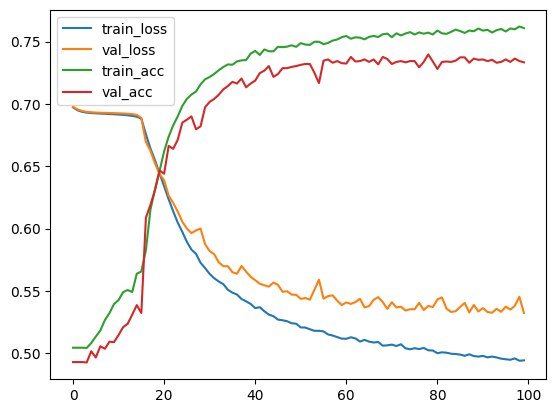

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs
})

df.plot()     # DataFrame 컬럼들을 한번에 라인 플롯으로 시각화
plt.show()

### Embedding + LSTM

In [16]:
# IMDB 감성분류 LSTM 모델 : 단어 ID 시퀀스를 Embedding으로 변환한 뒤 LSTM을 거쳐 감성 점수(logit)을 출력하는 모델
class SentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()              # nn.Module 초기화

        self.embedding = nn.Embedding(        # 단어 ID -> 임베딩 벡터로 변환
            num_embeddings = vocab_size,      # 단어 사전 크기
            embedding_dim = embedding_dim,    # 임베딩 차원 (각 차원을 embedding_dim 벡터로 표현)
            padding_idx = 0                   # PAD(0) 토큰 임베딩은 업데이트 하지 않는다.
        )

        self.lstm = nn.LSTM(
            input_size = embedding_dim, # 입력 feature 차원
            hidden_size = hidden_dim,   # 은닉 상태 차원
            batch_first = True          # 입력 shape이 (B, T, F) 형태
        )
        self.fc = nn.Linear(hidden_dim, output_dim)    # 마지막 hidden -> 출력(logit) 변환
    
    def forward(self, x):
        x = self.embedding(x)                  # (B, T) -> (B, T, E) 임베딩 변환
        output, (hidden, cell) = self.lstm(x)  # output : (B, T, H), hidden/ cell : (1:layers_num, B, H)
        output = self.fc(hidden[-1])           # 마지막 레이어 hidden (B, H) -> fc 적용
        return output                          # (B, output_dim) 반환

embedding_dim = 50        # 임베딩 벡터 차원
hidden_dim = 16           # RNN 은닉차원 수
output_dim = 1            # 이진 분류 출력(logit 1개)

model = SentimentNet(vocab_size, embedding_dim, hidden_dim, output_dim)
model

SentimentNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [17]:
# RNN 모델 파라미터(가중치/편향) 이름과 shape 확인
for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([300, 50])
lstm.weight_ih_l0 torch.Size([64, 50])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [18]:
# torchinfo로 모델 요약(summary) 확인
from torchinfo import summary

summary(model)  # 모델 레이어별 shape/파라미터 수 요약 출력

Layer (type:depth-idx)                   Param #
SentimentNet                             --
├─Embedding: 1-1                         15,000
├─LSTM: 1-2                              4,352
├─Linear: 1-3                            17
Total params: 19,369
Trainable params: 19,369
Non-trainable params: 0

In [19]:
### Embedding + LSTM(num_layers)

In [20]:
# LSTM 입력/출력 텐서
import torch
import torch.nn as nn

batch_size = 2     # B : 한번에 처리할 샘플(문장) 개수
seq_len = 3        # T : 시퀀스 길이(Time Steps)
input_size = 4     # F : 각 시점의 입력 차원 (vocab_size 또는 임베딩 차원)
hidden_size = 5    # H : RNN의 은닉 상태 차원

x = torch.randn(batch_size, seq_len, input_size)    # 입력 시퀀스 텐서 생성 : (B, T, F)
print(x.shape)

# LSTM 생성 ((B, T, F) 형태로 입력을 받도록 설정)
lstm = nn.LSTM(input_size, hidden_size, batch_first=True, num_layers=2)    # 2층 LSTM 생성
output, (hidden, cell) = lstm(x)    # 순전파 : output(전체 시점 출력), hidden(마지막 은닉)

print(output.shape)    # (B, T, H) : 모든 시점의 은닉 출력들이 쌓인 결과
print(hidden.shape)    # (Num_layers, B, H) : 마지막 시점 은닉 상태
print(cell.shape)      # (Num_layers, B, H) : 마지막 시점 cell state 

torch.Size([2, 3, 4])
torch.Size([2, 3, 5])
torch.Size([2, 2, 5])
torch.Size([2, 2, 5])


In [21]:
# IMDB 감성분류 LSTM 모델 : 단어 ID 시퀀스를 Embedding으로 변환한 뒤 LSTM을 거쳐 감성 점수(logit)을 출력하는 모델 (2-layer LSTM)
class SentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2):
        super().__init__()              # nn.Module 초기화

        self.embedding = nn.Embedding(        # 단어 ID -> 임베딩 벡터로 변환
            num_embeddings = vocab_size,      # 단어 사전 크기
            embedding_dim = embedding_dim,    # 임베딩 차원 (각 차원을 embedding_dim 벡터로 표현)
            padding_idx = 0                   # PAD(0) 토큰 임베딩은 업데이트 하지 않는다.
        )

        self.lstm = nn.LSTM(
            input_size = embedding_dim,  # 입력 feature 차원
            hidden_size = hidden_dim,    # 은닉 상태 차원
            batch_first = True,          # 입력 shape이 (B, T, F) 형태
            num_layers = num_layers
        )
        self.fc = nn.Linear(hidden_dim, output_dim)    # 마지막 hidden -> 출력(logit) 변환
    
    def forward(self, x):
        x = self.embedding(x)                  # (B, T) -> (B, T, E) 임베딩 변환
        output, (hidden, cell) = self.lstm(x)  # output : (B, T, H), hidden/ cell : (L:layers_num, B, H)
        output = self.fc(hidden[-1])           # 마지막 레이어 hidden (B, H) -> fc 적용
        return output                          # (B, output_dim) 반환

embedding_dim = 50        # 임베딩 벡터 차원
hidden_dim = 16           # RNN 은닉차원 수
output_dim = 1            # 이진 분류 출력(logit 1개)

model = SentimentNet(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2)
model

SentimentNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, num_layers=2, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [22]:
# RNN 모델 파라미터(가중치/편향) 이름과 shape 확인
for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([300, 50])
lstm.weight_ih_l0 torch.Size([64, 50])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
lstm.weight_ih_l1 torch.Size([64, 16])
lstm.weight_hh_l1 torch.Size([64, 16])
lstm.bias_ih_l1 torch.Size([64])
lstm.bias_hh_l1 torch.Size([64])
fc.weight torch.Size([1, 16])
fc.bias torch.Size([1])


In [23]:
# torchinfo로 모델 요약(summary) 확인
from torchinfo import summary

summary(model)  # 모델 레이어별 shape/파라미터 수 요약 출력

Layer (type:depth-idx)                   Param #
SentimentNet                             --
├─Embedding: 1-1                         15,000
├─LSTM: 1-2                              6,528
├─Linear: 1-3                            17
Total params: 21,545
Trainable params: 21,545
Non-trainable params: 0

파라미터 수에 따른 학습시간 계산에 사용한다. (x 데이터량)

### Emebedding + LSTM(bidirectional)

![](https://d.pr/i/0u69xz+)


**Bidirectional LSTM**은 LSTM의 변형 모델로, **양방향으로 데이터를 처리**할 수 있도록 설계된 구조이다. 일반 LSTM이 입력 데이터를 **순방향(forward)**으로만 처리하는 반면, Bidirectional LSTM은 **순방향**과 **역방향(backward)**으로 데이터를 동시에 처리하여 더 많은 정보를 학습한다.


1. **양방향 정보 학습**  
   - 순방향 LSTM은 이전 시점의 정보만을 사용하여 다음 시점의 출력을 계산한다.
   - Bidirectional LSTM은 데이터의 시간적 흐름을 순방향과 역방향으로 모두 고려하여 **이전**과 **이후**의 정보를 동시에 학습한다.

2. **문맥 정보 강화**  
   - 예를 들어, 텍스트 데이터를 처리할 때 문장의 맥락(Context)을 양방향으로 학습하여 더 정확한 결과를 얻을 수 있다.  
    - 예: "He went to the bank ..."에서 "bank"가 "은행"인지 "강둑"인지 구분하기 위해 이후 단어의 정보를 활용할 수 있다.
    - Forward LSTM:
    ```He → went → to → the → bank → to → withdraw → money```
    - Backward LSTM:
    ```money → withdraw → to → bank → the → to → went → He```


In [24]:
# LSTM 입력/출력 텐서
import torch
import torch.nn as nn

batch_size = 2     # B : 한번에 처리할 샘플(문장) 개수
seq_len = 3        # T : 시퀀스 길이(Time Steps)
input_size = 4     # F : 각 시점의 입력 차원 (vocab_size 또는 임베딩 차원)
hidden_size = 5    # H : RNN의 은닉 상태 차원

x = torch.randn(batch_size, seq_len, input_size)    # 입력 시퀀스 텐서 생성 : (B, T, F)
print(x.shape)

# LSTM 생성 ((B, T, F) 형태로 입력을 받도록 설정)
lstm = nn.LSTM(
    input_size,           # 입력 feature 차원 F : 각 시점에 들어오는 벡터 크기
    hidden_size,          # 은닉 상태 차원 H : LSTM hidden/cell state 크기
    batch_first=True,     # 입력/출력 텐서 shape을 (B, T, F)로 사용 (False : T, B, F 순으로 사용)
    num_layers=1,         # LSTM을 몇 층으로 쌓을지 (2이상이면 Stacked LSTM)
    bidirectional=True    # 양방향 LSTM 사용 여부 (출력 feature가 2H로 concat 됨)
)    # 양방향 LSTM
output, (hidden, cell) = lstm(x)    # 순전파 : output(전체 시점 출력), hidden(마지막 은닉)

print(output.shape)    # (B, T, H*2) : 모든 시점의 은닉 출력들이 쌓인 결과
print(hidden.shape)    # (Num_layers*2, B, H) : 마지막 시점 은닉 상태
print(cell.shape)      # (Num_layers*2, B, H) : 마지막 시점 cell state 

torch.Size([2, 3, 4])
torch.Size([2, 3, 10])
torch.Size([2, 2, 5])
torch.Size([2, 2, 5])


In [25]:
# IMDB 감성분류 LSTM 모델 : 단어 ID 시퀀스를 Embedding으로 변환한 뒤 BiLSTM(순/역방향)을 거쳐 두 방향을 hidden 결합 후, 감성 점수(logit)을 출력하는 모델
class SentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()              # nn.Module 초기화

        self.embedding = nn.Embedding(        # 단어 ID -> 임베딩 벡터로 변환
            num_embeddings = vocab_size,      # 단어 사전 크기
            embedding_dim = embedding_dim,    # 임베딩 차원 (각 차원을 embedding_dim 벡터로 표현)
            padding_idx = 0                   # PAD(0) 토큰 임베딩은 업데이트 하지 않는다.
        )

        self.lstm = nn.LSTM(
            input_size = embedding_dim,  # 입력 feature 차원
            hidden_size = hidden_dim,    # 은닉 상태 차원
            batch_first = True,          # 입력 shape이 (B, T, F) 형태
            bidirectional = True
        )
        # 이전 LSTM 출력은 hidden_dim의 2배 : (정방향+역방향) 결합 벡터
        self.fc = nn.Linear(hidden_dim * 2, output_dim)    # 마지막 hidden -> 출력(logit) 변환
    
    def forward(self, x):
        x = self.embedding(x)                  # (B, T) -> (B, T, E) 임베딩 변환
        _ , (hidden, _) = self.lstm(x)         # hidden: (num_layer*2, B, H) 반환 
        forward_pass = hidden[-2]              # 마지막 레이어의 정방향 hidden: (B, H)
        backward_pass = hidden[-1]             # 마지막 레이어의 역방향 hidden: (B, H)
        
        hidden = torch.cat((forward_pass, backward_pass), dim=1)  # (B, H) + (B, H) -> (B, 2H)로 concat

        output = self.fc(hidden)               # 마지막 레이어 hidden (B, 2H) -> fc 적용 (B, ouput_dim) 변환
        return output                          # (B, output_dim) 반환

embedding_dim = 50        # 임베딩 벡터 차원
hidden_dim = 16           # RNN 은닉차원 수
output_dim = 1            # 이진 분류 출력(logit 1개)

model = SentimentNet(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2)
model

SentimentNet(
  (embedding): Embedding(300, 50, padding_idx=0)
  (lstm): LSTM(50, 16, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [26]:
# RNN 모델 파라미터(가중치/편향) 이름과 shape 확인
for name, param in model.named_parameters():
    print(name, param.shape)    # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([300, 50])
lstm.weight_ih_l0 torch.Size([64, 50])
lstm.weight_hh_l0 torch.Size([64, 16])
lstm.bias_ih_l0 torch.Size([64])
lstm.bias_hh_l0 torch.Size([64])
lstm.weight_ih_l0_reverse torch.Size([64, 50])
lstm.weight_hh_l0_reverse torch.Size([64, 16])
lstm.bias_ih_l0_reverse torch.Size([64])
lstm.bias_hh_l0_reverse torch.Size([64])
fc.weight torch.Size([1, 32])
fc.bias torch.Size([1])


In [27]:
# torchinfo로 모델 요약(summary) 확인
from torchinfo import summary

summary(model)  # 모델 레이어별 shape/파라미터 수 요약 출력

Layer (type:depth-idx)                   Param #
SentimentNet                             --
├─Embedding: 1-1                         15,000
├─LSTM: 1-2                              8,704
├─Linear: 1-3                            33
Total params: 23,737
Trainable params: 23,737
Non-trainable params: 0

In [28]:
# 학습/검증/테스트 데이터 분리 및 DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64                                # 미니배치 크기
train_size = int(len(X_train_padded) * 0.8)    # 학습 데이터 개수 (80%)
val_size = len(X_train_padded) - train_size    # 검증 데이터 개수 (20%)

# 학습/검증/테스트 데이터셋 분리
train_dataset, val_dataset = random_split(TensorDataset(X_train_padded, y_train), [train_size, val_size])
test_dataset = TensorDataset(X_test_padded, y_test)    # 테스트 입력/라벨을 하나의 DataSet으로 묶음

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 학습용 : 섞어서 배치 생성
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)     # 검증용 : 순서 유지
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)   # 테스트용 : 순서 유지

학습시 X_*_padded(단어 ID 텐서)가 Embedding 입력으로 들어간다.

In [29]:
import torch

def get_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print("device =", device)

device = mps


In [30]:

# 0) Imports

import copy, gc, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from sklearn.metrics import roc_auc_score, average_precision_score


# 1) Device (MPS 우선)

def get_device():
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print("device =", device)


# 2) Safety: label / output shape 통일 유틸

def _reset_parameters(m: nn.Module):
    # 새 trial마다 가중치 초기화(가능한 모듈만)
    for layer in m.modules():
        if hasattr(layer, "reset_parameters"):
            layer.reset_parameters()

@torch.no_grad()
def predict_probs(model, dataloader, device):
    model.eval()
    probs_all, y_all = [], []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device).float().view(-1)          # (B,)
        logit = model(x).view(-1)                  # (B,)
        prob = torch.sigmoid(logit)                # (B,)

        probs_all.append(prob.detach().cpu().numpy())
        y_all.append(y.detach().cpu().numpy())

    probs_all = np.concatenate(probs_all) if probs_all else np.array([])
    y_all = np.concatenate(y_all) if y_all else np.array([])
    return y_all, probs_all

def train_one_trial(
    model,
    train_loader,
    val_loader,
    device,
    lr=1e-3,
    weight_decay=0.0,
    pos_weight=None,
    epochs=50,
    patience=10,
):
    model = model.to(device)

    # BCEWithLogitsLoss: logits 입력용
    if pos_weight is not None:
        pos_weight_t = torch.tensor([float(pos_weight)], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))

    best_val_pr = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, total, correct = 0.0, 0, 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)      # (B,)

            optimizer.zero_grad()
            logit = model(x).view(-1)              # (B,)
            loss = criterion(logit, y)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            prob = torch.sigmoid(logit)
            pred = (prob >= 0.5).float()
            correct += (pred == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / max(1, len(train_loader))
        train_acc = correct / max(1, total)

        # VAL: PR-AUC 기준으로 best 저장(불균형에 더 적합)
        y_val, p_val = predict_probs(model, val_loader, device)
        val_pr = float(average_precision_score(y_val, p_val)) if len(np.unique(y_val)) > 1 else 0.0
        val_roc = float(roc_auc_score(y_val, p_val)) if len(np.unique(y_val)) > 1 else 0.0

        print(f"Epoch {ep:03d} | train_loss={train_loss:.5f} train_acc={train_acc:.5f} | val_pr={val_pr:.5f} val_roc={val_roc:.5f}")

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopped at epoch {ep}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val_pr


# 3) Hyperparameter Search Space (원하면 줄이거나 늘리면 됨)

SPACE = {
    "lr": [1e-4, 3e-4, 1e-3],
    "weight_decay": [0.0, 1e-5, 1e-4],
    "pos_weight": [None, 2.0, 4.0],   # 양성(1)이 적으면 올리는 게 유리한 경우 많음
}
EPOCHS = 50
PATIENCE = 10
N_TRIALS = 12


# 4) Trial Loop (best만 저장)

# base_model은 "구조만" 재사용 / trial마다 reset해서 새로 학습
base_model = copy.deepcopy(model).cpu()
trials = []
best = None
best_state = None

# 랜덤 탐색(그리드보다 가볍고 빠름)
cand = [(lr, wd, pw) for lr in SPACE["lr"] for wd in SPACE["weight_decay"] for pw in SPACE["pos_weight"]]
random.Random(42).shuffle(cand)
cand = cand[:min(N_TRIALS, len(cand))]

for i, (lr, wd, pw) in enumerate(cand, 1):
    print(f"\n[TRIAL {i:02d}/{len(cand)}] lr={lr} wd={wd} pos_weight={pw}")

    m = copy.deepcopy(base_model)
    _reset_parameters(m)

    m, best_val_pr = train_one_trial(
        m,
        train_dataloader,
        val_dataloader,
        device=device,
        lr=lr,
        weight_decay=wd,
        pos_weight=pw,
        epochs=EPOCHS,
        patience=PATIENCE,
    )

    # 최종 VAL score 기록
    y_val, p_val = predict_probs(m, val_dataloader, device)
    val_pr = float(average_precision_score(y_val, p_val)) if len(np.unique(y_val)) > 1 else 0.0
    val_roc = float(roc_auc_score(y_val, p_val)) if len(np.unique(y_val)) > 1 else 0.0

    row = {
        "trial": i,
        "lr": float(lr),
        "weight_decay": float(wd),
        "pos_weight": None if pw is None else float(pw),
        "val_pr_auc": float(val_pr),
        "val_roc_auc": float(val_roc),
    }
    trials.append(row)

    print(f"TRIAL RESULT | val_pr_auc={val_pr:.5f} val_roc_auc={val_roc:.5f}")

    if (best is None) or (val_pr > best["val_pr_auc"]):
        best = row
        best_state = copy.deepcopy(m.state_dict())

    del m
    gc.collect()

import pandas as pd
trials_df = pd.DataFrame(trials).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
display(trials_df)

print("\nBEST HP:", best)


# 5) BEST로 모델 재구성 + TEST 평가

best_model = copy.deepcopy(base_model)
_reset_parameters(best_model)           # 구조 맞추기용(가중치 덮어씌울거라 큰 의미는 없음)
best_model.load_state_dict(best_state)
best_model = best_model.to(device)

y_test_np, p_test = predict_probs(best_model, test_dataloader, device)

test_pr = float(average_precision_score(y_test_np, p_test)) if len(np.unique(y_test_np)) > 1 else 0.0
test_roc = float(roc_auc_score(y_test_np, p_test)) if len(np.unique(y_test_np)) > 1 else 0.0

print(f"\nTEST ROC-AUC: {test_roc:.5f}")
print(f"TEST PR-AUC : {test_pr:.5f}")

device = mps

[TRIAL 01/12] lr=0.0003 wd=0.0001 pos_weight=2.0
Epoch 001 | train_loss=0.96725 train_acc=0.50392 | val_pr=0.52628 val_roc=0.53580
Epoch 002 | train_loss=0.94917 train_acc=0.50483 | val_pr=0.56118 val_roc=0.57527
Epoch 003 | train_loss=0.94081 train_acc=0.50483 | val_pr=0.59197 val_roc=0.60382
Epoch 004 | train_loss=0.93038 train_acc=0.50708 | val_pr=0.61454 val_roc=0.62545
Epoch 005 | train_loss=0.91806 train_acc=0.51233 | val_pr=0.63584 val_roc=0.64221
Epoch 006 | train_loss=0.90306 train_acc=0.53242 | val_pr=0.65674 val_roc=0.66889
Epoch 007 | train_loss=0.89100 train_acc=0.58325 | val_pr=0.67240 val_roc=0.68138
Epoch 008 | train_loss=0.87048 train_acc=0.59475 | val_pr=0.68868 val_roc=0.69743
Epoch 009 | train_loss=0.85699 train_acc=0.61533 | val_pr=0.70020 val_roc=0.71062
Epoch 010 | train_loss=0.83671 train_acc=0.64067 | val_pr=0.71575 val_roc=0.72654
Epoch 011 | train_loss=0.82040 train_acc=0.65583 | val_pr=0.72416 val_roc=0.73824
Epoch 012 | train_loss=0.80250 trai

,trial,lr,weight_decay,pos_weight,val_pr_auc,val_roc_auc
0,9,0.0003,0.00010,NaN,0.801772,0.814227
1,1,0.0003,0.00010,2.0,0.794562,0.809725
2,2,0.0003,0.00001,NaN,0.789831,0.806376
3,4,0.0010,0.00010,4.0,0.787381,0.801538
4,12,0.0010,0.00000,NaN,0.786090,0.796371
5,5,0.0010,0.00000,2.0,0.785568,0.799541
6,3,0.0003,0.00000,NaN,0.776948,0.796404
7,10,0.0010,0.00001,2.0,0.775653,0.800100
8,11,0.0003,0.00000,4.0,0.774501,0.793639
9,8,0.0003,0.00000,2.0,0.773638,0.793656



BEST HP: {'trial': 9, 'lr': 0.0003, 'weight_decay': 0.0001, 'pos_weight': None, 'val_pr_auc': 0.8017720192086896, 'val_roc_auc': 0.8142266185051404}

TEST ROC-AUC: 0.78895
TEST PR-AUC : 0.77951


In [35]:
last_train_loss = 0.43866
print(f"Epoch 050 (BEST TRIAL) train_loss: {last_train_loss:.5f} \n")

print(
    "BEST HP:",
    {
        "trial": int(best["trial"]),
        "lr": float(best["lr"]),
        "weight_decay": float(best["weight_decay"]),
        "pos_weight": best.get("pos_weight", None),
        "val_pr_auc": float(best["val_pr_auc"]),
        "val_roc_auc": float(best["val_roc_auc"]),
    },
    sep=" "
)

print(f"\nTEST ROC-AUC: {float(test_roc):.5f}")
print(f"TEST PR-AUC : {float(test_pr):.5f}")

Epoch 050 (BEST TRIAL) train_loss: 0.43866 

BEST HP: {'trial': 9, 'lr': 0.0003, 'weight_decay': 0.0001, 'pos_weight': None, 'val_pr_auc': 0.8017720192086896, 'val_roc_auc': 0.8142266185051404}

TEST ROC-AUC: 0.78895
TEST PR-AUC : 0.77951


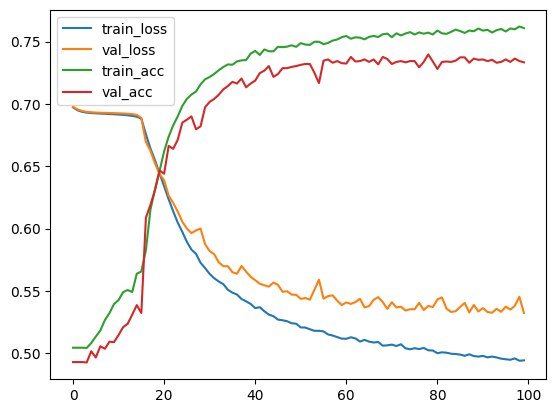

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs
})

df.plot()     # DataFrame 컬럼들을 한번에 라인 플롯으로 시각화
plt.show()